In [9]:
import kagglehub
import pandas as pd
import os
import re
from sklearn.model_selection import train_test_split
from collections import Counter
import math
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import sent_tokenize
from scipy.sparse import hstack, csr_matrix, save_npz
import numpy as np

In [2]:
df_preprocessed = pd.read_csv('downsampled.csv')

In [3]:
train_df, test_df = train_test_split(df_preprocessed, test_size=0.2, random_state=3, stratify=df_preprocessed['generated'])

In [4]:
# TF-IDF Vector
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_train = vectorizer.fit_transform(train_df['text'])
tfidf_test = vectorizer.transform(test_df['text'])
tfidf = vectorizer.transform(df_preprocessed['text'])

In [10]:
path = kagglehub.dataset_download("starblasters8/human-vs-llm-text-corpus")

print("Path to dataset files:", path)
os.listdir(path)

Path to dataset files: C:\Users\osten\.cache\kagglehub\datasets\starblasters8\human-vs-llm-text-corpus\versions\2


['data.csv',
 'data.parquet',
 'distribution.csv',
 'distribution.parquet',
 'prompts.csv',
 'prompts.parquet']

In [11]:
df_llm = pd.read_csv(os.path.join(path,'data.csv'))

In [14]:
df_llm['source'].value_counts()

source
1    441230
0    347692
Name: count, dtype: int64

In [16]:
df_ai = df_llm[df_llm['source']==1]
df_human = df_llm[df_llm['source']==0]

In [ ]:
df_ai = df_human.sample(n=len(df_human), random_state=3)

In [13]:
df_llm['source']=df_llm['source'].map(lambda x: 0 if x =='Human' else 1)

In [5]:
df_llm.drop(['prompt_id','text_length','word_count'],axis='columns',inplace=True)

In [6]:
df_llm=df_llm.sample(n=150000, random_state=1)

WORD CLOUD GENERATION

✓ Saved: wordcloud_comparison.png

AI text sample size: 172,764,898 chars
Human text sample size: 294,625,292 chars


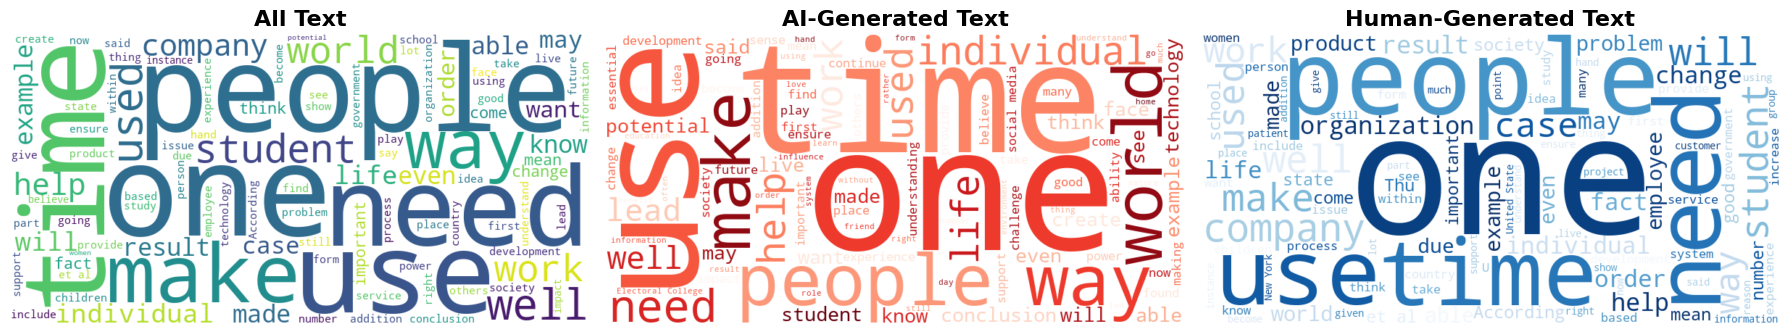

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

print("="*60)
print("WORD CLOUD GENERATION")
print("="*60)

ai_mask = df_llm['source'] == 1
human_mask = df_llm['source'] == 0

ai_text = ' '.join(df_llm[ai_mask]['text'].astype(str))
human_text = ' '.join(df_llm[human_mask]['text'].astype(str))
all_text = ' '.join(df_llm['text'].astype(str))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

wc_all = WordCloud(width=800, height=400, background_color='white', 
                   colormap='viridis', max_words=100).generate(all_text)
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].set_title('All Text', fontsize=16, fontweight='bold')
axes[0].axis('off')

wc_ai = WordCloud(width=800, height=400, background_color='white',
                  colormap='Reds', max_words=100).generate(ai_text)
axes[1].imshow(wc_ai, interpolation='bilinear')
axes[1].set_title('AI-Generated Text', fontsize=16, fontweight='bold')
axes[1].axis('off')

wc_human = WordCloud(width=800, height=400, background_color='white',
                     colormap='Blues', max_words=100).generate(human_text)
axes[2].imshow(wc_human, interpolation='bilinear')
axes[2].set_title('Human-Generated Text', fontsize=16, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('wordcloud_comparison.png', dpi=200, bbox_inches='tight')
print("\n✓ Saved: wordcloud_comparison.png")

print(f"\nAI text sample size: {len(ai_text):,} chars")
print(f"Human text sample size: {len(human_text):,} chars")

In [10]:
df_lower = df_llm.copy()

#Lowercasing
for col in df_lower.select_dtypes(include=['object']).columns:
        df_lower[col] = df_lower[col].str.lower()

#Noise Removal
def remove_noise(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z0-9.\s]', '', text)
    return text

df_lower['text'] = df_lower['text'].apply(remove_noise)

# Tokenization
df_lower['tokenized_text'] = df_lower['text'].apply(lambda x: x.split())

#Filtering
min_text_length = 30
df_filtered = df_lower[df_lower['tokenized_text'].apply(len) >= min_text_length].copy()

df_filtered

,text,source,tokenized_text
335533,recall that a current will reflect when there ...,0,"[recall, that, a, current, will, reflect, when..."
159312,hammurabis code and mosaic law impact on ameri...,0,"[hammurabis, code, and, mosaic, law, impact, o..."
670996,fantastic steakhouse. it has everything flemin...,1,"[fantastic, steakhouse., it, has, everything, ..."
250812,rational monotheism by edip yksel essay\n\ntab...,0,"[rational, monotheism, by, edip, yksel, essay,..."
225136,smart short medium and long term goals researc...,0,"[smart, short, medium, and, long, term, goals,..."
...,...,...,...
57472,1. military industry keeps some of the very fe...,1,"[1., military, industry, keeps, some, of, the,..."
726377,being sort of a narcissist i started writing a...,1,"[being, sort, of, a, narcissist, i, started, w..."
732906,citizens of the world it is time to take a sta...,1,"[citizens, of, the, world, it, is, time, to, t..."
549608,in todays globalized world cultural diplomacy...,1,"[in, todays, globalized, world, cultural, dipl..."


In [11]:
def preprocess(df):
    def calculate_entropy(text_tokens):
        if not text_tokens:
            return 0.0
        counts = Counter(text_tokens)
        probabilities = [count / len(text_tokens) for count in counts.values()]
        entropy = -sum(p * math.log2(p) for p in probabilities)
        return entropy
    def calculate_burstiness(text):
        if not isinstance(text, str):
            return 0.0 # Handle non-string input
        sentences = sent_tokenize(text)
        if len(sentences) < 2:
            return 0.0 # Need at least 2 sentences to calculate variance
        sentence_lengths = [len(s.split()) for s in sentences]
        # Avoid division by zero if all sentence lengths are the same
        if len(set(sentence_lengths)) == 1:
            return 0.0
        return pd.Series(sentence_lengths).var()
    def calculate_lexical_diversity(text_tokens):
        if not text_tokens:
            return 0.0
        return len(set(text_tokens)) / len(text_tokens)
    df['entropy'] = df['tokenized_text'].apply(calculate_entropy)
    df['burstiness'] = df['text'].apply(calculate_burstiness)
    df['lexical_diversity'] = df['tokenized_text'].apply(calculate_lexical_diversity)

    tfidf = vectorizer.transform(df['text'])

    X_numeric = df[['entropy', 'burstiness', 'lexical_diversity']].values
    
    X = hstack([tfidf,csr_matrix(X_numeric)])
    return X

In [12]:
y_validate = df_filtered['source']

In [13]:
x_validate = preprocess(df_filtered)

In [14]:
import pickle
tree = None  
with open('Tree fold 5.pkl', "rb") as f: # Take most recent
    tree = pickle.load(f)

In [15]:
from sklearn.metrics import accuracy_score

y_pred = tree.predict(x_validate)
accuracy = accuracy_score(y_validate, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6265503849926765


In [16]:
import pickle
SVC = None  
with open('SVC fold 5.pkl', "rb") as f: # Take most recent
    SVC = pickle.load(f)

In [17]:
y_pred = SVC.predict(x_validate)
accuracy = accuracy_score(y_validate, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5633927731566712


In [2]:
import tensorflow as tf
import tensorflow_text as text

2026-01-06 15:20:03.772086: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-06 15:20:03.838309: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-06 15:20:04.427738: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-06 15:20:04.431571: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/osten/miniconda3/envs/tf/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: Futur

In [3]:
bert = tf.keras.models.load_model(
    "bert_fold_5",
    compile=False
)

In [20]:
y_pred = bert.predict(df_filtered['text'])

4652/4652 [==============================] - 572s 123ms/step


In [23]:
y_pred

array([[0.9993068 ],
       [0.9975234 ],
       [0.00161926],
       ...,
       [0.9993772 ],
       [0.99943113],
       [0.9994111 ]], dtype=float32)

In [27]:
y_pred_int = np.round(y_pred).astype(np.int64)

In [28]:
accuracy = accuracy_score(y_validate, y_pred_int)

print("Accuracy:", accuracy)

Accuracy: 0.5953142427133585


In [29]:
lstm = tf.keras.models.load_model(
    "lstm_fold_5",
    compile=False
)

In [30]:
y_pred = lstm.predict(df_filtered['text'])

4652/4652 [==============================] - 137s 29ms/step


In [31]:
y_pred

array([[9.9954474e-01],
       [3.8235990e-04],
       [2.7719009e-04],
       ...,
       [9.9352294e-01],
       [1.0000000e+00],
       [9.9999976e-01]], dtype=float32)

In [32]:
y_pred_int = np.round(y_pred).astype(np.int64)

In [34]:
accuracy = accuracy_score(y_validate, y_pred_int)

print("Accuracy:", accuracy)

Accuracy: 0.5978002338175417
